In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping
from prophet import Prophet
import joblib
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [8]:
df = pd.read_csv("AAPL.csv")  # Adjust path as needed
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.set_index('Date', inplace=True)

In [9]:
print(df.head())

                 Open       High        Low      Close  Adj Close    Volume
Date                                                                       
2012-01-03  58.485714  58.928570  58.428570  58.747143  50.765709  75555200
2012-01-04  58.571430  59.240002  58.468571  59.062859  51.038536  65005500
2012-01-05  59.278572  59.792858  58.952858  59.718571  51.605175  67817400
2012-01-06  59.967144  60.392857  59.888573  60.342857  52.144630  79573200
2012-01-09  60.785713  61.107143  60.192856  60.247143  52.061932  98506100


In [10]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [11]:
print("\nBasic Statistics:")
print(df.describe())


Basic Statistics:
              Open         High          Low        Close    Adj Close  \
count  2011.000000  2011.000000  2011.000000  2011.000000  2011.000000   
mean    126.707469   127.827594   125.580258   126.741235   119.505548   
std      50.483753    50.926301    50.124940    50.578369    52.438444   
min      55.424286    57.085712    55.014286    55.790001    48.921928   
25%      85.882858    86.717858    85.056427    86.202145    75.056679   
50%     113.050003   114.190002   111.870003   113.050003   105.222908   
75%     165.190002   167.409996   163.424995   165.245002   160.047111   
max     291.119995   293.970001   288.119995   291.519989   289.522614   

             Volume  
count  2.011000e+03  
mean   5.949670e+07  
std    4.683856e+07  
min    1.136200e+07  
25%    2.758565e+07  
50%    4.346900e+07  
75%    7.471030e+07  
max    3.765300e+08  


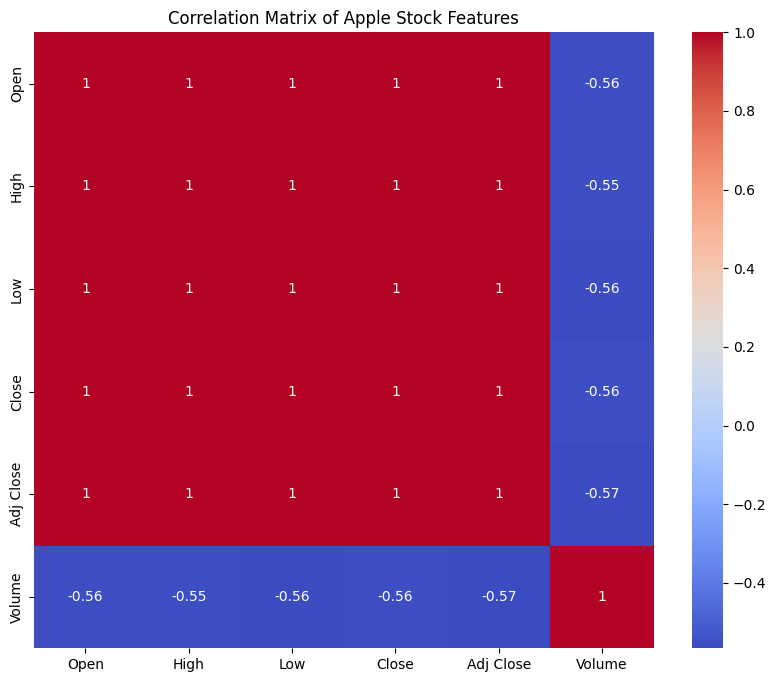

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Apple Stock Features')
plt.show()

In [13]:
df = df[['Close']].dropna()

In [14]:
print(df)

                 Close
Date                  
2012-01-03   58.747143
2012-01-04   59.062859
2012-01-05   59.718571
2012-01-06   60.342857
2012-01-09   60.247143
...                ...
2019-12-23  284.000000
2019-12-24  284.269989
2019-12-26  289.910004
2019-12-27  289.799988
2019-12-30  291.519989

[2011 rows x 1 columns]


In [15]:
split = int(len(df) * 0.8)
train, test = df[:split], df[split:]

In [16]:
arima_model = ARIMA(train, order=(5,1,0))  # (p,d,q)
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=len(test))
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print(f"ARIMA RMSE: {arima_rmse}")

c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA RMSE: 34.00632825433015


c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [17]:
sarima_model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.forecast(steps=len(test))
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
print(f"SARIMA RMSE: {sarima_rmse}")

c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


SARIMA RMSE: 26.360321230161595


c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
def create_features(data, lags=5):
    X, y = [], []
    for i in range(lags, len(data)):
        X.append(data[i-lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

close_prices = df['Close'].values
X, y = create_features(close_prices)
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f"XGBoost RMSE: {xgb_rmse}")

XGBoost RMSE: 33.03718271685699


In [19]:
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f"Random Forest RMSE: {rf_rmse}")

Random Forest RMSE: 33.22516762350793


In [20]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close']])

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

seq_len = 60
X_lstm, y_lstm = create_sequences(scaled_data, seq_len)
split = int(len(X_lstm) * 0.8)
X_train_lstm, y_train_lstm = X_lstm[:split], y_lstm[:split]
X_test_lstm, y_test_lstm = X_lstm[split:], y_lstm[split:]

X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(seq_len, 1)))
model_lstm.add(LSTM(units=50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')
early_stop = EarlyStopping(monitor='val_loss', patience=5)
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=32, validation_data=(X_test_lstm, y_test_lstm), callbacks=[early_stop])

lstm_pred = model_lstm.predict(X_test_lstm)
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test_lstm = scaler.inverse_transform([y_test_lstm])
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm.T, lstm_pred))
print(f"LSTM RMSE: {lstm_rmse}")

c:\Users\bindu\apple_stock_prediction\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.0122 - val_loss: 0.0019
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 3.5092e-04 - val_loss: 0.0017
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 3.1448e-04 - val_loss: 0.0020
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.7706e-04 - val_loss: 0.0014
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 2.7699e-04 - val_loss: 0.0014
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.5236e-04 - val_loss: 0.0012
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 2.5017e-04 - val_loss: 0.0013
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 2.5699e-04 - val_loss: 0.0013
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.3200e-04 - val_loss: 8.8395e-04
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 2.5267e-04 - val_loss: 8.0362e-04
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 2.0940e-04 - val_loss: 8.6033e-04
Epoch 12/20

In [21]:
# Forecast next 30 days
last_sequence = scaled_data[-seq_len:]
lstm_predictions = []
for _ in range(30):
    input_seq = last_sequence.reshape(1, seq_len, 1)
    pred = model_lstm.predict(input_seq, verbose=0)[0][0]
    lstm_predictions.append(pred)
    last_sequence = np.append(last_sequence[1:], [[pred]], axis=0)

lstm_forecast = scaler.inverse_transform(np.array(lstm_predictions).reshape(-1, 1)).flatten()
future_dates = pd.date_range(df.index[-1] + pd.Timedelta(days=1), periods=30)
lstm_forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Close': lstm_forecast})

In [22]:
prophet_df = df.reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})
train_prophet = prophet_df.iloc[:split]
test_prophet = prophet_df.iloc[split:]

prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(train_prophet)

# Evaluate Prophet
future = prophet_model.make_future_dataframe(periods=len(test_prophet))
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.iloc[split:]['yhat']
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))
print(f"Prophet RMSE: {prophet_rmse}")

22:12:34 - cmdstanpy - INFO - Chain [1] start processing
22:12:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 26.670090866586335


In [23]:
# Forecast next 30 days
future_30 = prophet_model.make_future_dataframe(periods=30, include_history=False)
prophet_future_forecast = prophet_model.predict(future_30)
prophet_forecast_df = prophet_future_forecast[['ds', 'yhat']].rename(columns={'ds': 'Date', 'yhat': 'Predicted_Close'})

In [27]:
# Save LSTM model and scaler
model_lstm.save('lstm_model.h5')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [25]:
# %% [Cell 16: Model Comparison]
print("\n--- Model Comparison ---")
print(f"ARIMA RMSE        : {arima_rmse:.2f}")
print(f"SARIMA RMSE       : {sarima_rmse:.2f}")
print(f"XGBoost RMSE      : {xgb_rmse:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"LSTM RMSE         : {lstm_rmse:.2f}")
print(f"Prophet RMSE      : {prophet_rmse:.2f}")


--- Model Comparison ---
ARIMA RMSE        : 34.01
SARIMA RMSE       : 26.36
XGBoost RMSE      : 33.04
Random Forest RMSE: 33.23
LSTM RMSE         : 5.44
Prophet RMSE      : 26.67


ValueError: x and y must have same first dimension, but have shapes (403,) and (402,)

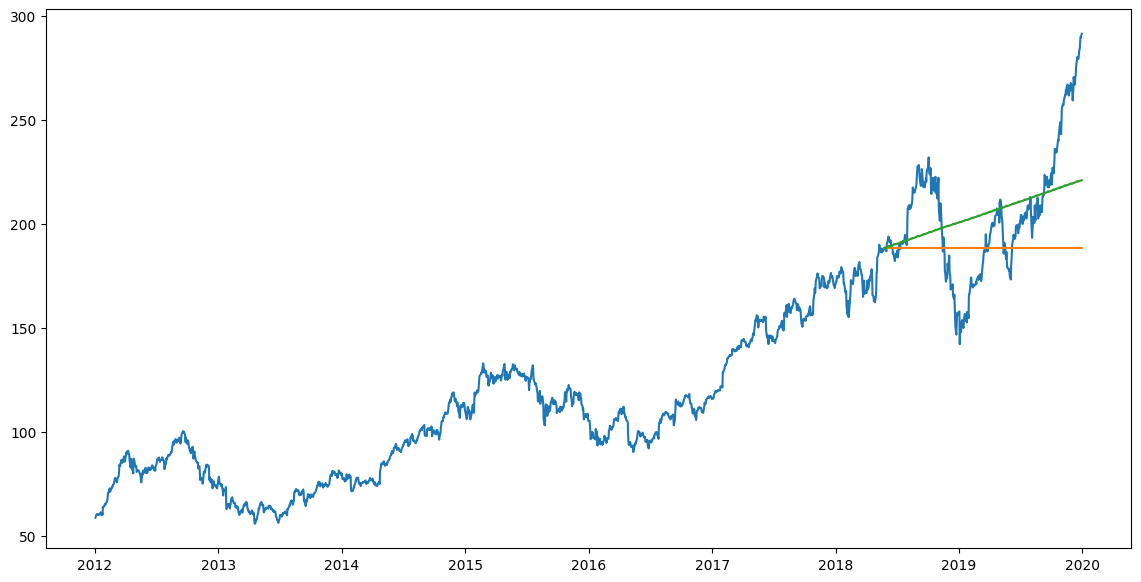

In [28]:
lstm_plot_index = df.index[-len(lstm_pred):]  # Align with length of lstm_pred

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Historical Close')
plt.plot(test.index, arima_forecast, label='ARIMA Forecast')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast')
plt.plot(test.index, xgb_pred, label='XGBoost Forecast')
plt.plot(test.index, rf_pred, label='Random Forest Forecast')
plt.plot(lstm_plot_index, lstm_pred, label='LSTM Forecast')  # Use adjusted index
plt.plot(test_prophet['ds'], prophet_pred, label='Prophet Forecast')
plt.title('Stock Price Forecasts')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()